In [1]:
import pandas as pd
import numpy as np
import sqlite3

conn = sqlite3.connect("../database/mutual_fund.db")

nav = pd.read_sql("SELECT * FROM fact_nav", conn)

conn.close()

print(nav.shape)
print(nav.columns)
nav.head()

(46000, 3)
Index(['amfi_code', 'date', 'nav'], dtype='str')


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [2]:
import pandas as pd

nav["date"] = pd.to_datetime(nav["date"], dayfirst=True)

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head()

ValueError: unconverted data remains when parsing with format "%Y-%d-%m": "3". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [3]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
print(nav["date"].head(10))

0    2022-01-03
1    2022-01-04
2    2022-01-05
3    2022-01-06
4    2022-01-07
5    2022-01-10
6    2022-01-11
7    2022-01-12
8    2022-01-13
9    2022-01-14
Name: date, dtype: str


In [5]:
nav["date"] = pd.to_datetime(nav["date"], errors="coerce")

In [6]:
nav["date"].head()

0   2022-01-03
1   2022-01-04
2   2022-01-05
3   2022-01-06
4   2022-01-07
Name: date, dtype: datetime64[us]

In [7]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [9]:
nav["date"] = pd.to_datetime(nav["date"])

In [10]:
import pandas as pd

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [11]:
risk_free_rate = 0.05

sharpe_ratio = nav.groupby("amfi_code")["daily_return"].apply(
    lambda x: ((x.mean() * 252) - risk_free_rate) /
              (x.std() * (252 ** 0.5))
)

sharpe_df = sharpe_ratio.reset_index()

sharpe_df.columns = ["amfi_code", "sharpe_ratio"]

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

,amfi_code,sharpe_ratio
27,120507,3.532698
31,120844,2.833423
5,101208,2.146301
34,148567,1.553972
30,120843,1.401161
36,148569,1.319800
19,119551,1.317425
25,120505,1.257858
38,149323,1.216647
9,118632,1.187679


In [12]:
risk_free_rate = 0.05

sharpe_ratio = nav.groupby("amfi_code")["daily_return"].apply(
    lambda x: ((x.mean() * 252) - risk_free_rate) /
              (x.std() * (252 ** 0.5))
)

sharpe_df = sharpe_ratio.reset_index()

sharpe_df.columns = ["amfi_code", "sharpe_ratio"]

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

,amfi_code,sharpe_ratio
27,120507,3.532698
31,120844,2.833423
5,101208,2.146301
34,148567,1.553972
30,120843,1.401161
36,148569,1.319800
19,119551,1.317425
25,120505,1.257858
38,149323,1.216647
9,118632,1.187679


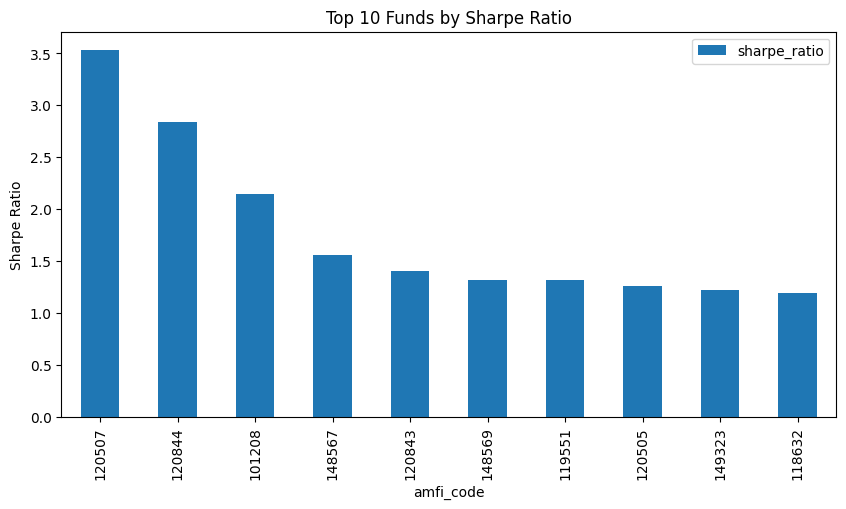

In [13]:
import matplotlib.pyplot as plt

top10 = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

top10.plot(
    x="amfi_code",
    y="sharpe_ratio",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.ylabel("Sharpe Ratio")

plt.show()

In [15]:
risk_free_rate = 0.05

def sortino_ratio(returns):
    downside = returns[returns < 0]

    if len(downside) == 0:
        return None

    return ((returns.mean() * 252) - risk_free_rate) / (
        downside.std() * np.sqrt(252)
    )

sortino_df = nav.groupby("amfi_code")["daily_return"].apply(sortino_ratio)

sortino_df = sortino_df.reset_index()

sortino_df.columns = ["amfi_code", "sortino_ratio"]

sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head(10)

,amfi_code,sortino_ratio
27,120507,7.497802
31,120844,5.993409
5,101208,4.423930
34,148567,2.559723
30,120843,2.535151
19,119551,2.333626
36,148569,2.294460
25,120505,2.163067
9,118632,2.031474
38,149323,2.015098


In [16]:
def max_drawdown(nav_series):
    rolling_max = nav_series.cummax()

    drawdown = (nav_series - rolling_max) / rolling_max

    return drawdown.min()

drawdown_df = nav.groupby("amfi_code")["nav"].apply(max_drawdown)

drawdown_df = drawdown_df.reset_index()

drawdown_df.columns = ["amfi_code", "max_drawdown"]

drawdown_df.sort_values("max_drawdown").head(10)

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


In [17]:
var_df = nav.groupby("amfi_code")["daily_return"].apply(
    lambda x: np.percentile(x.dropna(), 5)
)

var_df = var_df.reset_index()

var_df.columns = ["amfi_code", "VaR_95"]

var_df.head(10)

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021
5,101208,-0.000269
6,102885,-0.012613
7,102886,-0.019220
8,102887,-0.015232
9,118632,-0.013954


In [18]:
var_df = nav.groupby("amfi_code")["daily_return"].apply(
    lambda x: np.percentile(x.dropna(), 5)
)

var_df = var_df.reset_index()

var_df.columns = ["amfi_code", "VaR_95"]

var_df.head(10)

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021
5,101208,-0.000269
6,102885,-0.012613
7,102886,-0.019220
8,102887,-0.015232
9,118632,-0.013954


In [19]:
sharpe_df.to_csv("../reports/sharpe_ratio.csv", index=False)

sortino_df.to_csv("../reports/sortino_ratio.csv", index=False)

drawdown_df.to_csv("../reports/max_drawdown.csv", index=False)

var_df.to_csv("../reports/var_95.csv", index=False)

print("Risk Analytics Reports Saved!")

Risk Analytics Reports Saved!


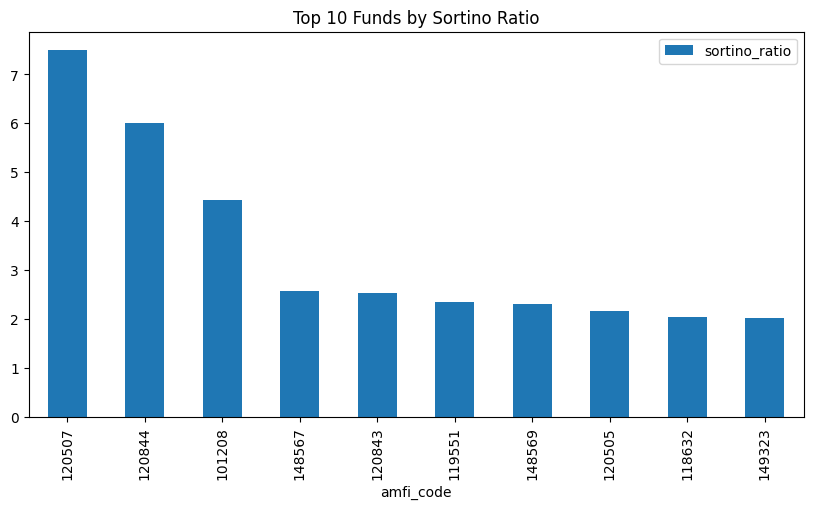

In [20]:
top10_sortino = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head(10)

top10_sortino.plot(
    x="amfi_code",
    y="sortino_ratio",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.show()

In [22]:
risk_free_rate = 0.05

def sortino_ratio(returns):
    downside = returns[returns < 0]

    if len(downside) == 0:
        return None

    return ((returns.mean() * 252) - risk_free_rate) / (
        downside.std() * np.sqrt(252)
    )

sortino_df = nav.groupby("amfi_code")["daily_return"].apply(sortino_ratio)

sortino_df = sortino_df.reset_index()

sortino_df.columns = ["amfi_code", "sortino_ratio"]

sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head(10)

,amfi_code,sortino_ratio
27,120507,7.497802
31,120844,5.993409
5,101208,4.423930
34,148567,2.559723
30,120843,2.535151
19,119551,2.333626
36,148569,2.294460
25,120505,2.163067
9,118632,2.031474
38,149323,2.015098


In [23]:
def max_drawdown(nav_series):
    rolling_max = nav_series.cummax()

    drawdown = (nav_series - rolling_max) / rolling_max

    return drawdown.min()

drawdown_df = nav.groupby("amfi_code")["nav"].apply(max_drawdown)

drawdown_df = drawdown_df.reset_index()

drawdown_df.columns = ["amfi_code", "max_drawdown"]

drawdown_df.sort_values("max_drawdown").head(10)

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


In [25]:
var_df = nav.groupby("amfi_code")["daily_return"].apply(
    lambda x: np.percentile(x.dropna(), 5)
)

var_df = var_df.reset_index()

var_df.columns = ["amfi_code", "VaR_95"]

var_df.head(10)

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021
5,101208,-0.000269
6,102885,-0.012613
7,102886,-0.019220
8,102887,-0.015232
9,118632,-0.013954


In [30]:
sharpe_df.to_csv("../reports/sharpe_ratio.csv", index=False)

sortino_df.to_csv("../reports/sortino_ratio.csv", index=False)

drawdown_df.to_csv("../reports/max_drawdown.csv", index=False)

var_df.to_csv("../reports/var_95.csv", index=False)

print("Risk Analytics Reports Saved!")

Risk Analytics Reports Saved!
